In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

In [2]:
# ANALYSIS SPECIFIC DIRECTORIES
ana_directory = "../../1muNp0pi_Nge1_uncontained"
data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'


Processing systematics for sample: mc
--Systematic(statistical, None)--
	Fractional uncertainty: 0.32%
--Systematic(stats, Stat.)--
	Fractional uncertainty: 0.32%
--Systematic(MC_total, All Systematics (No G4))--
	Fractional uncertainty: 0.32%

Processing systematics for sample: mc_nonmatched

Processing systematics for sample: onbeam

Processing systematics for sample: offbeam
Setting weight for mc to 3.03e-02
Setting weight for mc_nonmatched to 3.03e-02
Setting weight for onbeam to 1.00e+00
Setting weight for offbeam to 9.53e-02


/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/vertex_x/../../../spectra1d.py:706: RuntimeWarning: invalid value encountered in divide
  f"Fractional - Min: {(uncertainty / y_pred).min():.2%}, Max: {(uncertainty / y_pred).max():.2%}")


Fractional - Min: nan%, Max: nan%


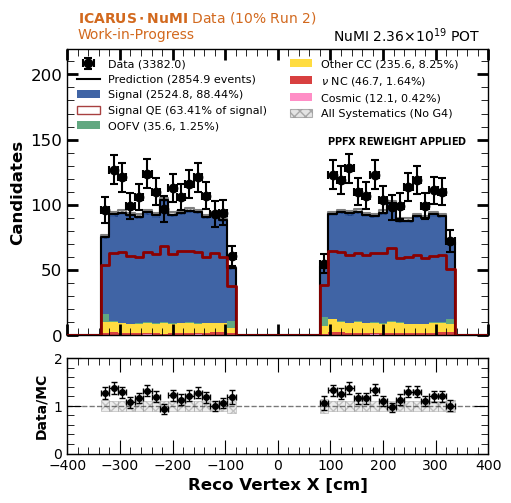

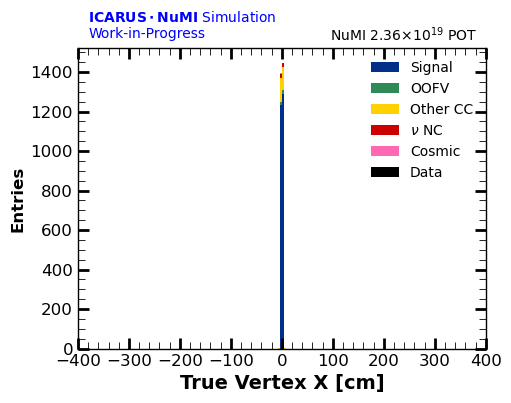

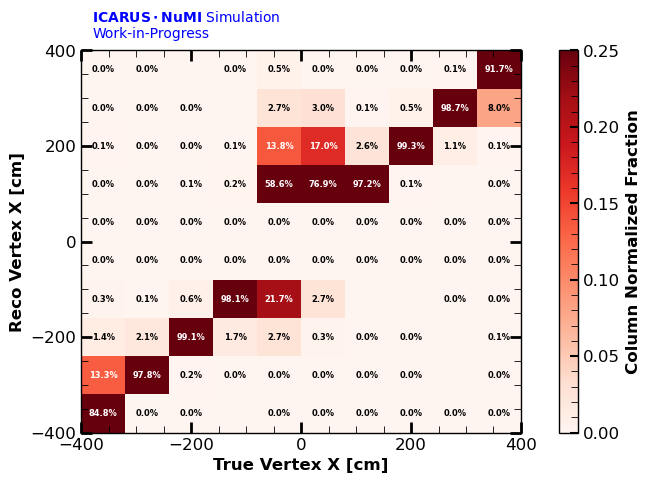

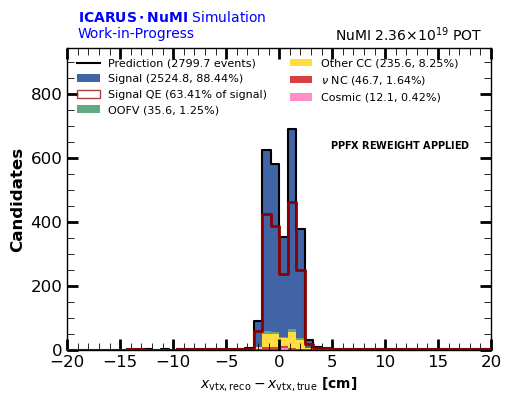

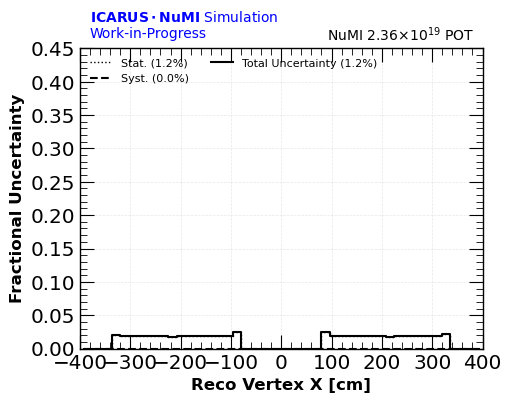

In [3]:
analysis = Analysis(ana_directory + '/vertex_x/vertex_x.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# File and tree
fpath = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam_withPCA.root'

with uproot.open(fpath) as f:
    tree = f['events/full/selected']
    reco_vtx_x    = tree['reco_vertex_x'].array(library='np')
    true_vtx_x    = tree['true_vertex_x'].array(library='np')
    true_category = tree['true_category'].array(library='np')

# Signal categories
signal_mask = np.isin(true_category, [0, 1, 3, 4])

# Valid kinematics mask
valid_mask = (
    np.isfinite(true_vtx_x) &
    np.isfinite(reco_vtx_x)
)

# Compute absolute residual
abs_residual = reco_vtx_x - true_vtx_x

# Combined mask
combined_mask = signal_mask & valid_mask

# Binning
x_bins = np.linspace(-400, 400, 41)
y_bins = np.linspace(-20, 20, 51)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

h, xedges, yedges = np.histogram2d(
    true_vtx_x[combined_mask],
    abs_residual[combined_mask],
    bins=[x_bins, y_bins]
)

im = ax.imshow(
    h.T,
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    origin='lower',
    norm=mcolors.LogNorm(vmin=1, vmax=h.max()),
    cmap='magma'
)

ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_xlabel('True Vertex X [cm]', fontsize=12, fontweight='bold')
ax.set_ylabel(r'$x_{\mathrm{vtx,reco}} - x_{\mathrm{vtx,true}}$ [cm]', fontsize=12, fontweight='bold')
ax.set_title('Vertex X Resolution', fontsize=13, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=11, size=6, width=1.5)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Signal Events', fontsize=11, fontweight='bold')
cbar.ax.tick_params(labelsize=10)

plt.savefig('pdf/vertex_x_resolution_vs_true.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Vertex X cross-section uncertainties
analysis = Analysis(ana_directory + '/vertex_x/vertex_x_xSecUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Vertex X cross-section uncertainties expanded
analysis = Analysis(ana_directory + '/vertex_x/vertex_x_xSecUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Vertex X flux uncertainties
analysis = Analysis(ana_directory + '/vertex_x/vertex_x_FluxUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Vertex X flux uncertainties expanded
analysis = Analysis(ana_directory + '/vertex_x/vertex_x_FluxUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Vertex X detector uncertainties
analysis = Analysis(ana_directory + '/vertex_x/vertex_x_DetectorUncertainty.toml', data_file)
analysis.run(close_figs=False)

## Validation checks

Independent checks of three claims made about the vertex_x plots: (1) a possible normalization offset between data and MC, (2) whether the double-peak/dip-at-zero shape in the residual plot is a binning artifact, (3) how much reco/true migration occurs near the cathode gap in the smearing matrix.


In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

fpath_val = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'
fval = uproot.open(fpath_val)

# Signal categories per common/vertex_x.toml category_assignment: total signal = {0,1,3,4}
SIGNAL_CATS = [0, 1, 3, 4]
STACK_GROUPS = {
    'signal':   [0, 1, 3, 4],
    'cc1pi':    [6],
    'other_cc': [7, 8, 9],
    'nc':       [10],
    'oofv':     [2, 5],
}


### 1. Data/MC normalization offset

Claim: in the `vertex_x` ratio panel, most bins sit above 1 rather than being randomly scattered around 1, suggesting a possible normalization offset rather than pure statistical noise. Build the data histogram and the weighted MC prediction independently (same weighting scheme as `Sample.set_weight`: `weight = (onbeam_POT / sample_POT) * ppfx_cv_weight` where available), then run a sign test on the ratio and compare the overall data/MC normalization.


Bins with data/MC > 1: 25 / 32
Bins with data/MC < 1: 7 / 32
Sign-test p-value (H0: bins equally likely above/below 1): 0.0021

Total data: 3382
Total weighted MC (selected+nonmatched only, no rock/offbeam 'Others'): 3100.4 +/- 9.8 (MC stat only)
Data/MC overall ratio: 1.091 +/- 0.019 (data stat only, MC stat not propagated)
Note: 'Others' (rock+offbeam cosmic contributions, ~1% of total per the plot legend) is not included here,
so N_mc is expected to sit slightly below the official prediction total shown in vertex_x.jpeg.


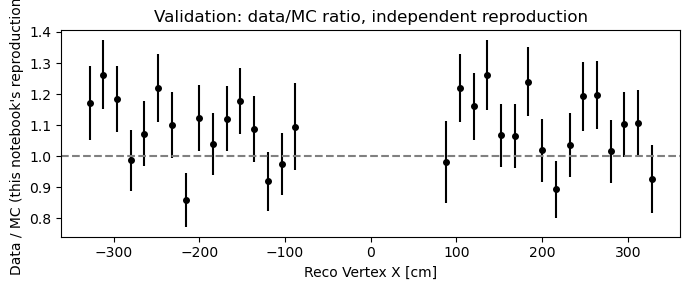

In [2]:
# --- Data histogram (onbeam sample) ---
onbeam_pot_override = 2.36124e19
mc_pot_override = 7.178390e20

t_data = fval['events/onbeam/selected']
x_data = t_data['reco_vertex_x'].array(library='np')

bins = np.linspace(-400, 400, 51)
h_data, edges = np.histogram(x_data, bins=bins)

# --- Weighted MC prediction (full/selected + full/selected_nonmatched) ---
scale_mc = onbeam_pot_override / mc_pot_override

t_sel = fval['events/full/selected']
sel = t_sel.arrays(['reco_vertex_x', 'ppfx_cv_weight'], library='np')
w_sel = scale_mc * sel['ppfx_cv_weight']

t_nm = fval['events/full/selected_nonmatched']
nm = t_nm.arrays(['reco_vertex_x'], library='np')
w_nm = scale_mc * np.ones(len(nm['reco_vertex_x']))

x_mc = np.concatenate([sel['reco_vertex_x'], nm['reco_vertex_x']])
w_mc = np.concatenate([w_sel, w_nm])

h_mc, _ = np.histogram(x_mc, bins=bins, weights=w_mc)
h_mc_var, _ = np.histogram(x_mc, bins=bins, weights=w_mc**2)  # MC stat variance per bin

# --- Ratio + sign test ---
nonzero = h_mc > 0
ratio = np.full_like(h_mc, np.nan)
ratio[nonzero] = h_data[nonzero] / h_mc[nonzero]

n_above = np.sum(ratio[nonzero] > 1)
n_below = np.sum(ratio[nonzero] < 1)
n_total = n_above + n_below

from scipy.stats import binomtest
sign_test = binomtest(n_above, n_total, p=0.5)

print(f"Bins with data/MC > 1: {n_above} / {n_total}")
print(f"Bins with data/MC < 1: {n_below} / {n_total}")
print(f"Sign-test p-value (H0: bins equally likely above/below 1): {sign_test.pvalue:.4f}")

N_data = h_data.sum()
N_mc = h_mc.sum()
N_mc_stat_err = np.sqrt(h_mc_var.sum())
print(f"\nTotal data: {N_data}")
print(f"Total weighted MC (selected+nonmatched only, no rock/offbeam 'Others'): {N_mc:.1f} +/- {N_mc_stat_err:.1f} (MC stat only)")
print(f"Data/MC overall ratio: {N_data/N_mc:.3f} +/- {np.sqrt(N_data)/N_mc:.3f} (data stat only, MC stat not propagated)")
print("Note: 'Others' (rock+offbeam cosmic contributions, ~1% of total per the plot legend) is not included here,")
print("so N_mc is expected to sit slightly below the official prediction total shown in vertex_x.jpeg.")

fig, ax = plt.subplots(figsize=(7, 3))
centers = 0.5 * (edges[1:] + edges[:-1])
ax.errorbar(centers[nonzero], ratio[nonzero], yerr=np.sqrt(h_data[nonzero])/h_mc[nonzero], fmt='o', color='k', ms=4)
ax.axhline(1, color='gray', ls='--')
ax.set_xlabel('Reco Vertex X [cm]')
ax.set_ylabel('Data / MC (this notebook\'s reproduction)')
ax.set_title('Validation: data/MC ratio, independent reproduction')
plt.tight_layout()
plt.show()


### 2. Residual double-peak: binning artifact check

Claim: the dip at 0 / peaks near ±1 cm in `vertex_x_absolute_residual.jpeg` come from the histogram binning (50 bins over [-20, 20] cm places a bin **edge** exactly at 0, not a bin **center**), not from a real reconstruction bias. Test by rebinning with an edge shifted by half a bin width so a bin is centered on 0, and compare.


Original binning: is 0 a bin edge? True
Shifted binning: is 0 a bin edge? False


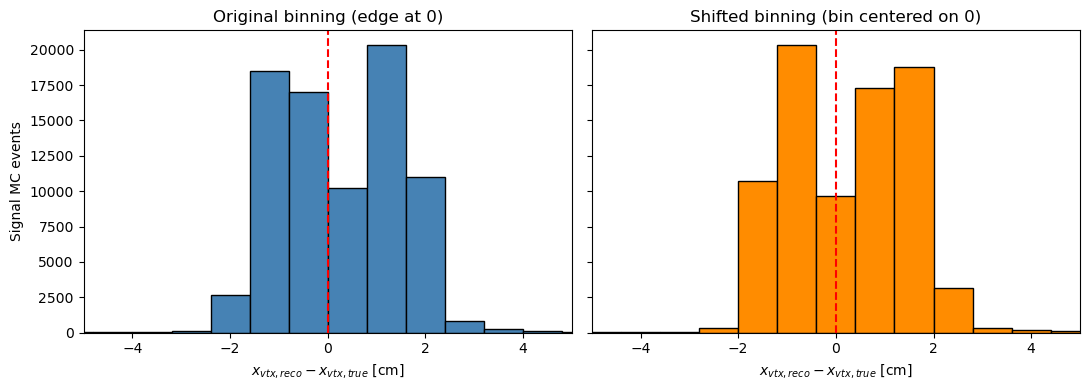


Original binning: bins adjacent to 0 = 17025, 10221 (dip at the 0 edge straddled by these two bins)
Shifted binning: bin centered on 0 = 9686, neighbors = 20345, 17322
If the shifted-binning peak count at/near 0 is comparable to or higher than its neighbors (no dip),
the double-peak in the original plot is a binning artifact rather than a real reconstruction bias.


In [3]:
t_sel2 = fval['events/full/selected']
sel2 = t_sel2.arrays(['reco_vertex_x', 'true_vertex_x', 'true_category'], library='np')
signal_mask = np.isin(sel2['true_category'], SIGNAL_CATS)
residual = (sel2['reco_vertex_x'] - sel2['true_vertex_x'])[signal_mask]

# Original binning as configured in vertex_x.toml: nbins=50, range=[-20,20] -> bin width 0.8 cm, edge at 0
bins_orig = np.linspace(-20, 20, 51)
h_orig, edges_orig = np.histogram(residual, bins=bins_orig)

# Shifted binning: same bin width, but shifted by half a bin so a bin is CENTERED at 0
half_width = (bins_orig[1] - bins_orig[0]) / 2
bins_shifted = bins_orig - half_width
# extend range symmetrically so we don't lose the last bin
bins_shifted = np.append(bins_shifted, bins_shifted[-1] + (bins_orig[1]-bins_orig[0]))
h_shifted, edges_shifted = np.histogram(residual, bins=bins_shifted)

print(f"Original binning: is 0 a bin edge? {0 in np.round(bins_orig, 6)}")
print(f"Shifted binning: is 0 a bin edge? {0 in np.round(bins_shifted, 6)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
c_orig = 0.5*(edges_orig[1:]+edges_orig[:-1])
c_shift = 0.5*(edges_shifted[1:]+edges_shifted[:-1])
axes[0].bar(c_orig, h_orig, width=edges_orig[1]-edges_orig[0], color='steelblue', edgecolor='k')
axes[0].axvline(0, color='red', ls='--')
axes[0].set_title('Original binning (edge at 0)')
axes[0].set_xlim(-5, 5)
axes[1].bar(c_shift, h_shifted, width=edges_shifted[1]-edges_shifted[0], color='darkorange', edgecolor='k')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Shifted binning (bin centered on 0)')
axes[1].set_xlim(-5, 5)
for ax in axes:
    ax.set_xlabel(r'$x_{vtx,reco} - x_{vtx,true}$ [cm]')
axes[0].set_ylabel('Signal MC events')
plt.tight_layout()
plt.show()

# Quantify: peak-to-dip ratio around zero for each binning
mid_orig = len(h_orig)//2
mid_shift = len(h_shifted)//2
print(f"\nOriginal binning: bins adjacent to 0 = {h_orig[mid_orig-1]}, {h_orig[mid_orig]} (dip at the 0 edge straddled by these two bins)")
print(f"Shifted binning: bin centered on 0 = {h_shifted[mid_shift]}, neighbors = {h_shifted[mid_shift-1]}, {h_shifted[mid_shift+1]}")
print("If the shifted-binning peak count at/near 0 is comparable to or higher than its neighbors (no dip),")
print("the double-peak in the original plot is a binning artifact rather than a real reconstruction bias.")


### 3. Smearing matrix: migration near the cathode gap

Claim: the large off-diagonal entries in `vertex_x_smearing_matrix_normalized.jpeg` are concentrated in true-X bins adjacent to the cathode gap (|X| < ~160 cm), consistent with vertices near the TPC boundary migrating across it, rather than being spread uniformly across the whole range.


In [4]:
t_sel3 = fval['events/full/selected']
sel3 = t_sel3.arrays(['reco_vertex_x', 'true_vertex_x', 'true_category'], library='np')
signal_mask3 = np.isin(sel3['true_category'], SIGNAL_CATS)
true_x = sel3['true_vertex_x'][signal_mask3]
reco_x = sel3['reco_vertex_x'][signal_mask3]

# Same binning as reco_vertex_x_smearing / true_vertex_x_smearing in common/vertex_x.toml: nbins=10, range=[-400,400]
bins10 = np.linspace(-400, 400, 11)
H, xedges, yedges = np.histogram2d(true_x, reco_x, bins=[bins10, bins10])

# Column-normalize (normalize each true-X column to sum to 1), matching 'show_option = smearing'
col_sums = H.sum(axis=1, keepdims=True)
col_sums[col_sums == 0] = 1
H_norm = H / col_sums

diag_frac = np.diag(H_norm)
offdiag_frac = 1 - diag_frac

bin_centers = 0.5*(bins10[1:]+bins10[:-1])
near_gap = np.abs(bin_centers) < 160   # bins adjacent to the cathode gap
far_gap = ~near_gap

print("True-X bin center [cm] | on-diagonal fraction | off-diagonal (migration) fraction")
for c, d, o in zip(bin_centers, diag_frac, offdiag_frac):
    tag = ' <- near cathode gap' if abs(c) < 160 else ''
    print(f"{c:8.1f}                | {d:6.1%}               | {o:6.1%}{tag}")

print(f"\nMean migration fraction, bins near gap (|X|<160cm): {offdiag_frac[near_gap].mean():.1%}")
print(f"Mean migration fraction, bins far from gap (|X|>=160cm): {offdiag_frac[far_gap].mean():.1%}")


True-X bin center [cm] | on-diagonal fraction | off-diagonal (migration) fraction
  -360.0                |  91.1%               |   8.9%
  -280.0                |  98.3%               |   1.7%
  -200.0                |  99.6%               |   0.4%
  -120.0                |  98.4%               |   1.6% <- near cathode gap
   -40.0                |   0.0%               | 100.0% <- near cathode gap
    40.0                |   0.0%               | 100.0% <- near cathode gap
   120.0                |  97.7%               |   2.3% <- near cathode gap
   200.0                |  99.7%               |   0.3%
   280.0                |  98.9%               |   1.1%
   360.0                |  92.0%               |   8.0%

Mean migration fraction, bins near gap (|X|<160cm): 51.0%
Mean migration fraction, bins far from gap (|X|>=160cm): 3.4%
